<a href="https://colab.research.google.com/github/dede0702/hp-governanca-ia-business-analytics/blob/Sprint-1/An%C3%A1lise_de_Indicadores_por_Regi%C3%A3o_e_Tipo_de_Produto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
1. Importar bibliotecas
Importamos as bibliotecas necessárias para manipulação de dados (pandas, numpy) e visualização (matplotlib, seaborn).
```



In [35]:
import pandas as pd           # Manipulação de dados em tabelas
import numpy as np            # Funções matemáticas e geração de números aleatórios
import matplotlib.pyplot as plt   # Visualização gráfica básica
import seaborn as sns         # Visualização gráfica avançada e estilizada




```
2. Configurações para gráficos e resultados replicáveis
Define um estilo para os gráficos com seaborn e fixa a semente aleatória para garantir a reprodutibilidade dos números gerados.

```



In [36]:
sns.set(style="whitegrid")    # Estilo dos gráficos com fundo branco e grade
np.random.seed(42)            # Semente fixa para que os dados aleatórios sejam sempre os mesmos



```
3. Criar as listas de regiões e tipos
Definimos as regiões e os tipos de produto que serão usados para gerar os dados.
```



In [37]:
regioes = ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte']
tipos = ['Original', 'Genérico']




```
4. Gerar os dados sintéticos
Para cada combinação de região e tipo, criamos dados simulados para os indicadores: Chamados, Taxa_Devolucao e NPS.
```



In [38]:
dados = []

for regiao in regioes:
    for tipo in tipos:
        # Chamados: maior volume para Genérico
        if tipo == 'Original':
            chamados = np.random.randint(50, 200)
            devolucao = np.random.uniform(0.02, 0.05)  # Taxa de devolução menor
            nps = np.random.randint(50, 70)            # NPS mais alto e positivo
        else:
            chamados = np.random.randint(150, 300)
            devolucao = np.random.uniform(0.1, 0.25)   # Taxa de devolução maior
            nps = np.random.randint(-20, 10)           # NPS baixo, pode ser negativo

        dados.append({
            'Região': regiao,
            'Tipo': tipo,
            'Chamados': chamados,
            'Taxa_Devolucao': devolucao,
            'NPS': nps
        })



```
5. Criar o DataFrame
Transformamos a lista de dicionários em um DataFrame do pandas para facilitar a análise.
```



In [39]:
df = pd.DataFrame(dados)

In [40]:
# Mostrar o DataFrame formatado para visualização
print("Tabela com os dados gerados:\n")
print(df.to_string(index=False))

Tabela com os dados gerados:

      Região     Tipo  Chamados  Taxa_Devolucao  NPS
     Sudeste Original       152        0.043896   64
     Sudeste Genérico       256        0.216954    0
         Sul Original       152        0.033375   60
         Sul Genérico       237        0.150056  -13
    Nordeste Original       180        0.020618   51
    Nordeste Genérico       237        0.224866  -15
Centro-Oeste Original       179        0.025455   50
Centro-Oeste Genérico       207        0.178713   -9
       Norte Original       138        0.028737   59
       Norte Genérico       164        0.168410   -6




```
6. Plotar gráficos
Visualizamos os dados em três gráficos de barras, um para cada indicador, separados por Região e diferenciados por Tipo.
```



In [41]:
# Função para formatar a taxa de devolução em percentual nos gráficos
def percentual(x, pos):
    return f'{x*100:.1f}%'

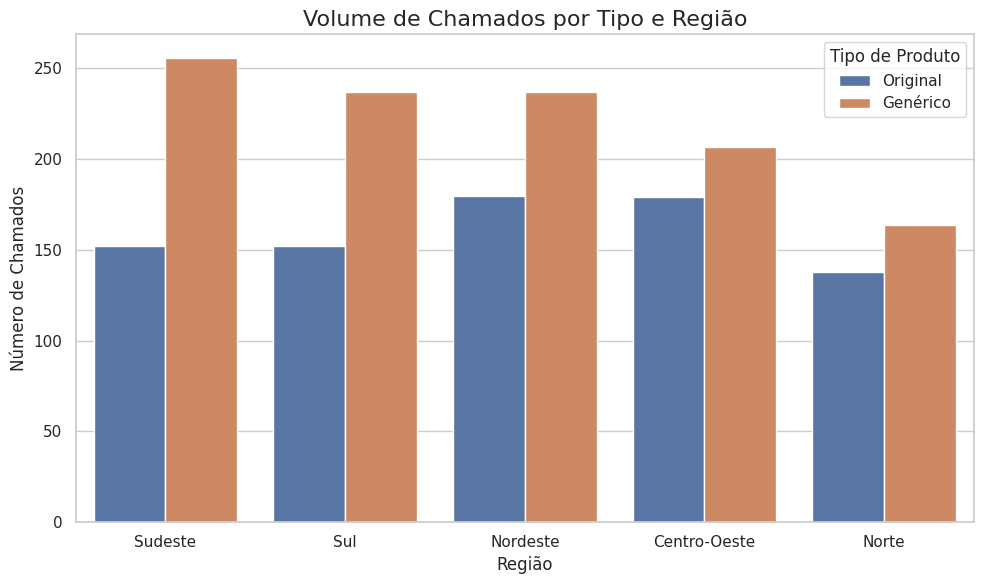

In [42]:
# --- Gráfico 1: Volume de Chamados ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Região', y='Chamados', hue='Tipo', data=df)
plt.title('Volume de Chamados por Tipo e Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Número de Chamados', fontsize=12)
plt.legend(title='Tipo de Produto')
plt.tight_layout()
plt.show()

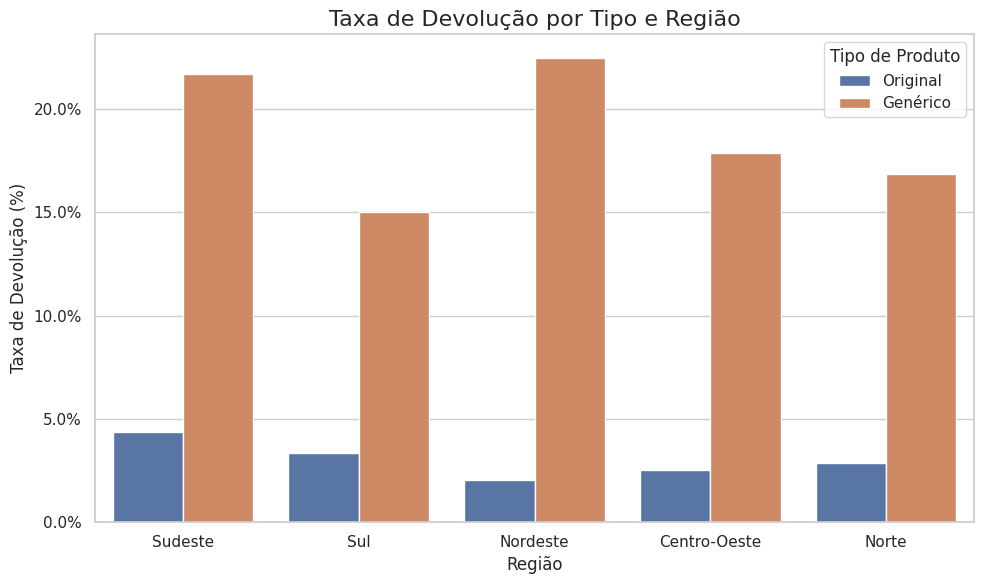

In [48]:
# --- Gráfico 2: Taxa de Devolução ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Região', y='Taxa_Devolucao', hue='Tipo', data=df)
plt.title('Taxa de Devolução por Tipo e Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Taxa de Devolução (%)', fontsize=12)
plt.legend(title='Tipo de Produto')

# Formatar eixo y para mostrar % com 1 casa decimal
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(percentual))

plt.tight_layout()
plt.show()


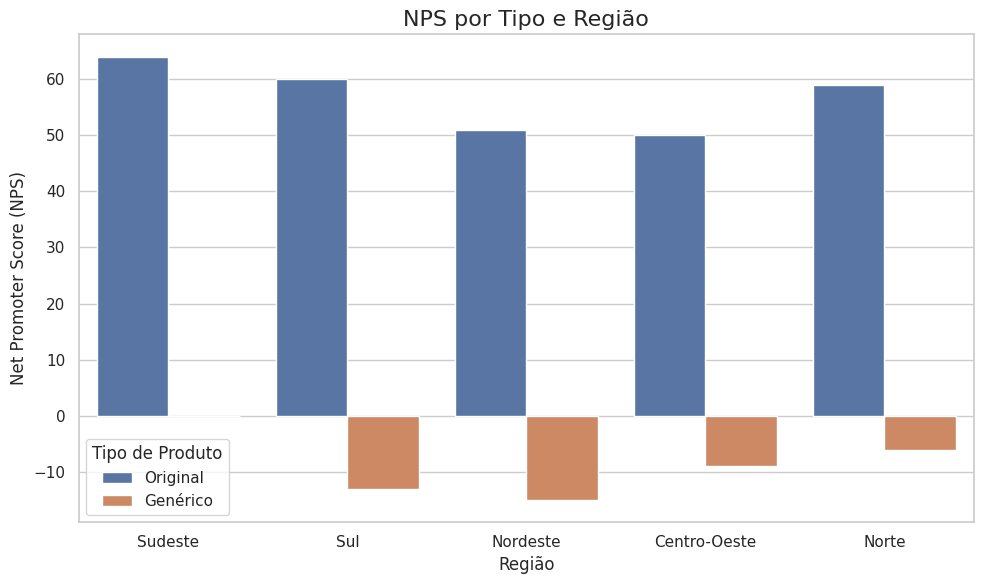

In [45]:
# --- Gráfico 3: NPS ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Região', y='NPS', hue='Tipo', data=df)
plt.title('NPS por Tipo e Região', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Net Promoter Score (NPS)', fontsize=12)
plt.legend(title='Tipo de Produto')
plt.tight_layout()
plt.show()



```
6. Análise rápida dos dados (exemplo simples)
```



In [46]:
print("\nResumo estatístico dos dados numéricos:")
print(df.describe())



Resumo estatístico dos dados numéricos:
         Chamados  Taxa_Devolucao       NPS
count   10.000000       10.000000  10.00000
mean   190.200000        0.109108  24.10000
std     41.568685        0.085859  34.92993
min    138.000000        0.020618 -15.00000
25%    155.000000        0.029896  -8.25000
50%    179.500000        0.096976  25.00000
75%    229.500000        0.176138  57.00000
max    256.000000        0.224866  64.00000


In [47]:
# Separar os dados por tipo para análise comparativa
print("\nMédia dos indicadores por tipo de produto:")
print(df.groupby('Tipo')[['Chamados', 'Taxa_Devolucao', 'NPS']].mean())


Média dos indicadores por tipo de produto:
          Chamados  Taxa_Devolucao   NPS
Tipo                                    
Genérico     220.2        0.187800  -8.6
Original     160.2        0.030416  56.8
